In [4]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 4
BASE = 'round4'
DAYS = ['1', '2', '3']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices_r4 = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices_r4[col] = pd.to_numeric(prices_r4[col], errors='coerce')

hp_prices_r4  = prices_r4[prices_r4['product'] == 'HYDROGEL_PACK'].reset_index(drop=True)
vfe_prices_r4 = prices_r4[prices_r4['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)

print(f'HYDROGEL_PACK rows      : {len(hp_prices_r4)}')
print(f'VELVETFRUIT_EXTRACT rows: {len(vfe_prices_r4)}')

HYDROGEL_PACK rows      : 30000
VELVETFRUIT_EXTRACT rows: 30000


In [5]:
DAYS = ['0', '1', '2']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'../ROUND3/round3/prices_round_3_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices_r3 = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices_r3[col] = pd.to_numeric(prices_r3[col], errors='coerce')

hp_prices_r3  = prices_r3[prices_r3['product'] == 'HYDROGEL_PACK'].reset_index(drop=True)
vfe_prices_r3 = prices_r3[prices_r3['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)

print(f'HYDROGEL_PACK rows      : {len(hp_prices_r3)}')
print(f'VELVETFRUIT_EXTRACT rows: {len(vfe_prices_r3)}')

HYDROGEL_PACK rows      : 30000
VELVETFRUIT_EXTRACT rows: 30000


In [6]:
assert len(hp_prices_r3) == len(hp_prices_r4), "Row counts differ between rounds for HYDROGEL_PACK"
n = len(hp_prices_r3)
for i in range(n):
    if not np.all(hp_prices_r3.iloc[i] == hp_prices_r4.iloc[i]):
        print("Difference at row", i)

Difference at row 0
Difference at row 1
Difference at row 2
Difference at row 3
Difference at row 4
Difference at row 5
Difference at row 6
Difference at row 7
Difference at row 8
Difference at row 9
Difference at row 10
Difference at row 11
Difference at row 12
Difference at row 13
Difference at row 14
Difference at row 15
Difference at row 16
Difference at row 17
Difference at row 18
Difference at row 19
Difference at row 20
Difference at row 21
Difference at row 22
Difference at row 23
Difference at row 24
Difference at row 25
Difference at row 26
Difference at row 27
Difference at row 28
Difference at row 29
Difference at row 30
Difference at row 31
Difference at row 32
Difference at row 33
Difference at row 34
Difference at row 35
Difference at row 36
Difference at row 37
Difference at row 38
Difference at row 39
Difference at row 40
Difference at row 41
Difference at row 42
Difference at row 43
Difference at row 44
Difference at row 45
Difference at row 46
Difference at row 47
Di

In [7]:
assert len(vfe_prices_r3) == len(vfe_prices_r4), "Row counts differ between rounds for VELVETFRUIT_EXTRACT"
n = len(vfe_prices_r3)
for i in range(n):
    if not np.all(vfe_prices_r3.iloc[i] == vfe_prices_r4.iloc[i]):
        print("Difference at row", i)

Difference at row 0
Difference at row 1
Difference at row 2
Difference at row 3
Difference at row 4
Difference at row 5
Difference at row 6
Difference at row 7
Difference at row 8
Difference at row 9
Difference at row 10
Difference at row 11
Difference at row 12
Difference at row 13
Difference at row 14
Difference at row 15
Difference at row 16
Difference at row 17
Difference at row 18
Difference at row 19
Difference at row 20
Difference at row 21
Difference at row 22
Difference at row 23
Difference at row 24
Difference at row 25
Difference at row 26
Difference at row 27
Difference at row 28
Difference at row 29
Difference at row 30
Difference at row 31
Difference at row 32
Difference at row 33
Difference at row 34
Difference at row 35
Difference at row 36
Difference at row 37
Difference at row 38
Difference at row 39
Difference at row 40
Difference at row 41
Difference at row 42
Difference at row 43
Difference at row 44
Difference at row 45
Difference at row 46
Difference at row 47
Di

In [8]:
ROUND_NUM = 4
DAYS = ['1', '2', '3']

trade_rows = []
offset = 0
for day in DAYS:
    with open(f'{BASE}/trades_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            #mid = row['mid_price']
            #if not mid or float(mid) == 0:
            #    continue
            row['timestamp'] = int(row['timestamp']) + offset
            trade_rows.append(row)
    offset += 1_000_000

trades_r4 = pd.DataFrame(trade_rows)
for col in ['timestamp', 'price', 'quantity']:
    trades_r4[col] = pd.to_numeric(trades_r4[col], errors='coerce')

hp_trades_r4  = trades_r4[trades_r4['symbol'] == 'HYDROGEL_PACK'].reset_index(drop=True)
vfe_trades_r4 = trades_r4[trades_r4['symbol'] != 'HYDROGEL_PACK'].reset_index(drop=True)

print(f'HYDROGEL_PACK rows      : {len(hp_trades_r4)}')
print(f'VELVETFRUIT_EXTRACT rows (incl. options): {len(vfe_trades_r4)}')

HYDROGEL_PACK rows      : 1022
VELVETFRUIT_EXTRACT rows (incl. options): 3259


In [9]:
ROUND_NUM = 3
DAYS = ['0', '1', '2']

trade_rows = []
offset = 0
for day in DAYS:
    with open(f'../ROUND3/round3/trades_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            #mid = row['mid_price']
            #if not mid or float(mid) == 0:
            #    continue
            row['timestamp'] = int(row['timestamp']) + offset
            trade_rows.append(row)
    offset += 1_000_000

trades_r3 = pd.DataFrame(trade_rows)
for col in ['timestamp', 'price', 'quantity']:
    trades_r3[col] = pd.to_numeric(trades_r3[col], errors='coerce')

hp_trades_r3  = trades_r3[trades_r3['symbol'] == 'HYDROGEL_PACK'].reset_index(drop=True)
vfe_trades_r3 = trades_r3[trades_r3['symbol'] != 'HYDROGEL_PACK'].reset_index(drop=True)

print(f'HYDROGEL_PACK rows      : {len(hp_trades_r3)}')
print(f'VELVETFRUIT_EXTRACT rows (incl. options): {len(vfe_trades_r3)}')

HYDROGEL_PACK rows      : 1010
VELVETFRUIT_EXTRACT rows (incl. options): 3038


In [10]:
prices = prices_r4
option = lambda s: prices[prices['product'] == f'VEV_{s}'].mid_price
extract = prices[prices['product'] == 'VELVETFRUIT_EXTRACT'].mid_price
np.corrcoef(option(5200), extract)

array([[1.        , 0.92865365],
       [0.92865365, 1.        ]])

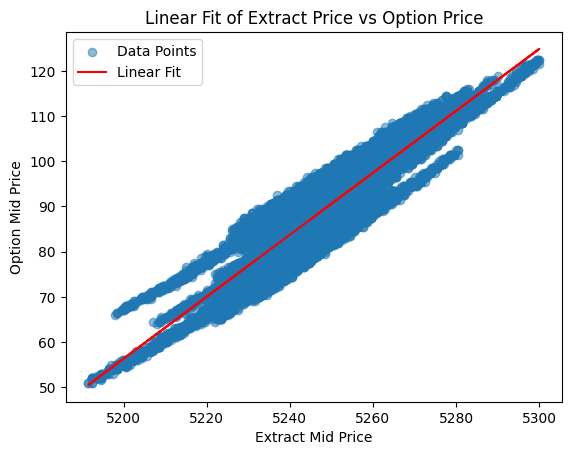

In [11]:
# Fit a quadratic regression to see if there's a non-linear relationship
X = extract.values.reshape(-1, 1)
X_quad = np.hstack([X])
y = option(5200).values
model = LinearRegression().fit(X_quad, y)
y_pred = model.predict(X_quad)
plt.scatter(extract, option(5200), alpha=0.5, label='Data Points')
plt.plot(extract, y_pred, color='red', label='Linear Fit')
plt.xlabel('Extract Mid Price')
plt.ylabel('Option Mid Price')
plt.title('Linear Fit of Extract Price vs Option Price')
plt.legend()
plt.show()

Coefficients:
[0.68565758]
Intercept:
-3509.096657061972


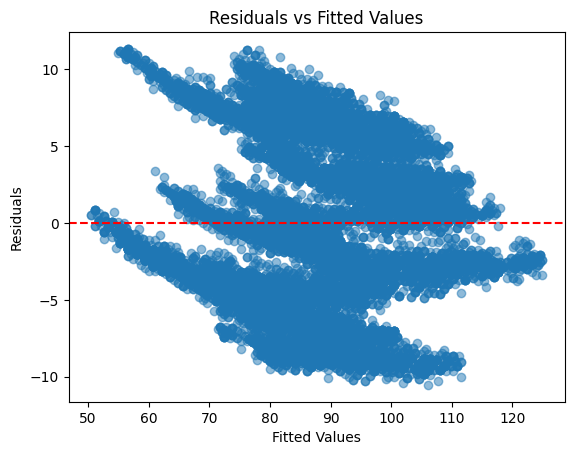

In [12]:
# Print the coefficients and plot residuals vs fitted
print("Coefficients:")
print(model.coef_)
print("Intercept:")
print(model.intercept_)
residuals = y - y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

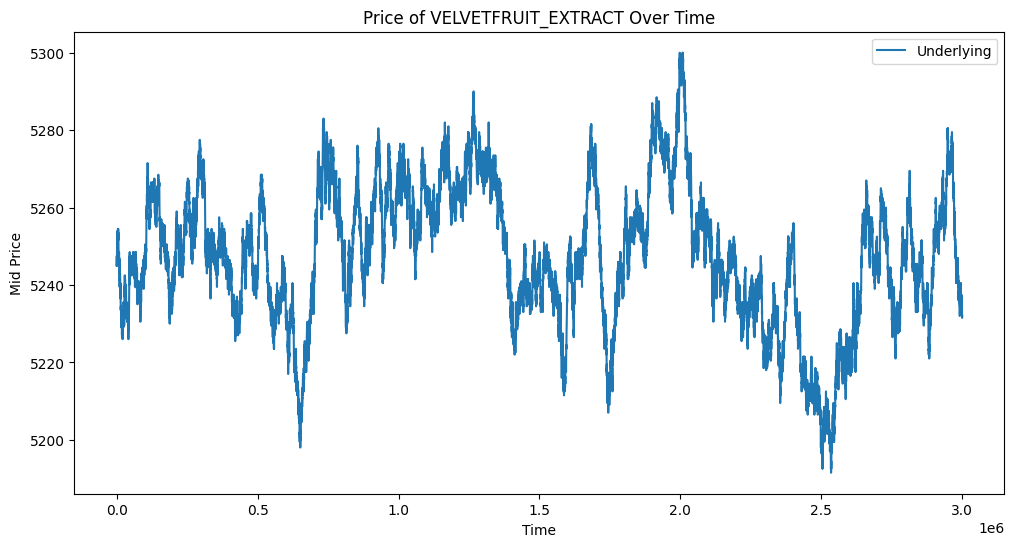

In [13]:
# Plotting the price for VELVETFRUIT_EXTRACT
underlying = prices[prices['product'] == 'VELVETFRUIT_EXTRACT'][['timestamp', 'mid_price']]
ulr3 = prices_r3[prices_r3['product'] == 'VELVETFRUIT_EXTRACT'][['timestamp', 'mid_price']]
plt.figure(figsize=(12, 6))
plt.plot(underlying['timestamp'], underlying['mid_price'], label='Underlying')
#plt.plot(ulr3['timestamp'], ulr3['mid_price'], label='R3')
plt.title('Price of VELVETFRUIT_EXTRACT Over Time')
plt.xlabel('Time')
plt.ylabel('Mid Price')
plt.legend()
plt.show()

In [14]:
underlying.mid_price.describe()
x2 = underlying.mid_price.shift(2)
x1 = underlying.mid_price.shift(1)
y = underlying.mid_price
# Linear regression to get the AR(2) coefficients
data = pd.DataFrame({'y': y, 'x1': x1, 'x2': x2}).dropna()
model = LinearRegression().fit(data[['x1', 'x2']], data['y'])
print("AR(2) Coefficients:")
print(model.coef_)
print("AR(2) Intercept:")
print(model.intercept_)

AR(2) Coefficients:
[0.83895506 0.15939495]
AR(2) Intercept:
8.658032543547051


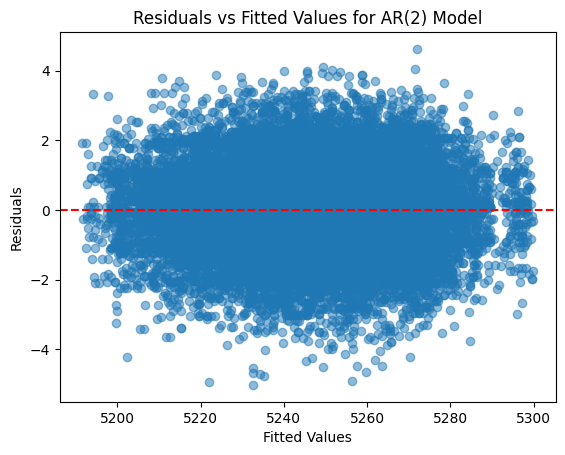

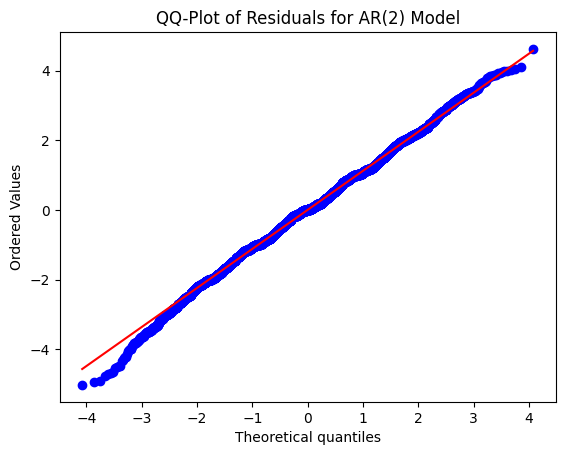

In [15]:
# Plot residuals vs fitted values for the AR(2) model, and also a QQ-plot for normality of residuals
y_pred = model.predict(data[['x1', 'x2']])
residuals = data['y'] - y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values for AR(2) Model')
plt.show()

stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ-Plot of Residuals for AR(2) Model')
plt.show()

In [16]:
beta1 = model.coef_[0]
beta2 = model.coef_[1]
alpha = model.intercept_
mu = alpha / (1 - beta1 - beta2)
delta = beta1**2 + 4 * beta2
r1 = (beta1 + np.sqrt(delta)) / 2
r2 = (beta1 - np.sqrt(delta)) / 2
mu, beta1, beta2, r1, r2

(np.float64(5247.3331044672705),
 np.float64(0.8389550609958958),
 np.float64(0.15939495178751678),
 np.float64(0.9985771336580378),
 np.float64(-0.159622072662142))

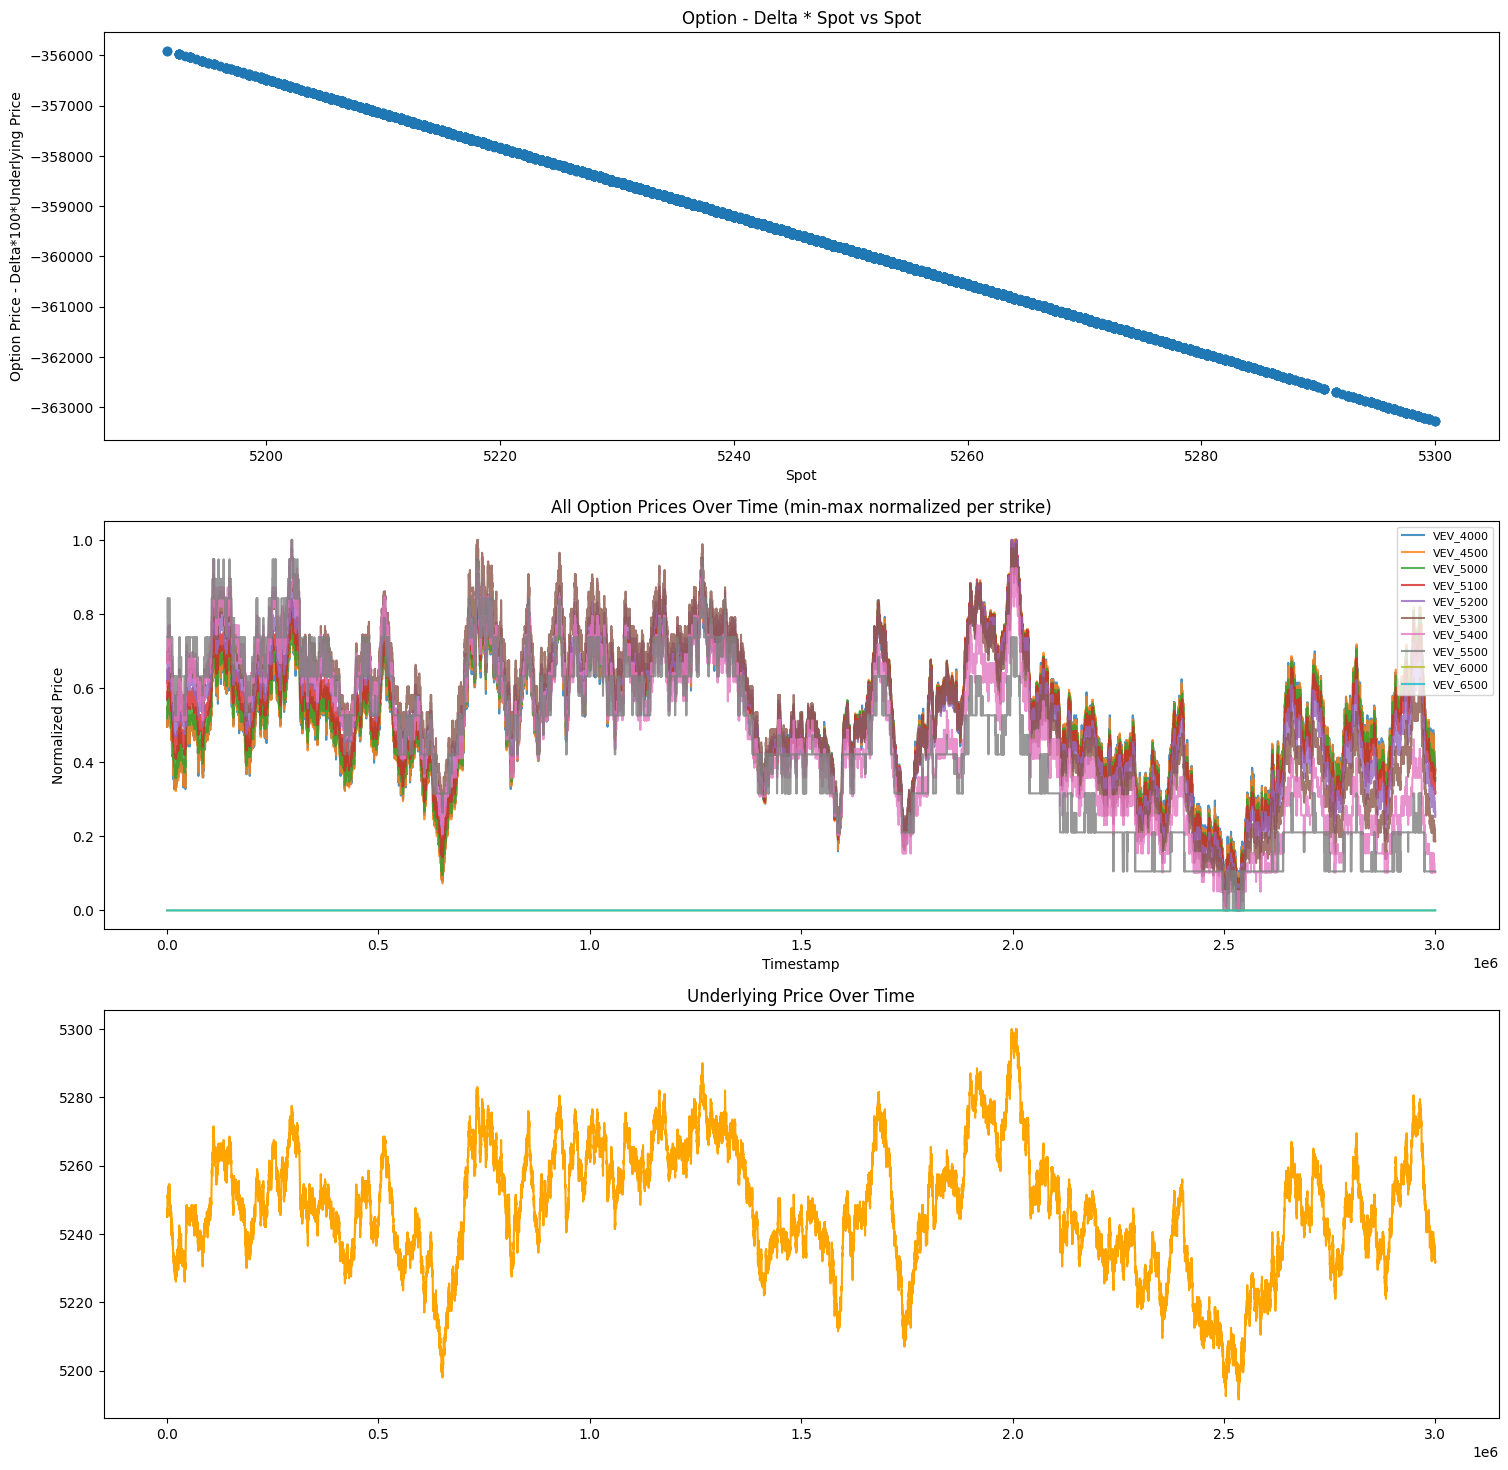

In [17]:
# Plot the difference between the option price and the underlying price over time to see if there's any visible pattern
# Also plot the option price and underlying price on different graphs to visually inspect their relationship

STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 18))
axes[0].scatter(underlying.mid_price, np.array(option(5200)) - 0.68565758*100*np.array(underlying.mid_price))
axes[0].set_title('Option - Delta * Spot vs Spot')
axes[0].set_xlabel('Spot')
axes[0].set_ylabel('Option Price - Delta*100*Underlying Price')

for K in STRIKES:
    prices_k = np.array(option(K), dtype=float)
    lo, hi = prices_k.min(), prices_k.max()
    normalized = (prices_k - lo) / (hi - lo) if hi > lo else np.zeros_like(prices_k)
    axes[1].plot(underlying.timestamp, normalized, label=f'VEV_{K}', alpha=0.8)
axes[1].set_title('All Option Prices Over Time (min-max normalized per strike)')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Normalized Price')
axes[1].legend(loc='upper right', fontsize=8)

axes[2].plot(underlying.timestamp, underlying.mid_price, label='Underlying Price', color='orange')
axes[2].set_title('Underlying Price Over Time')
plt.show()

In [18]:
TTE = 4_000_000 // 100 # t increments by 100, and there are 1_000_000 in a day (ie 10_000 time steps per day)
psi = lambda j: (( r1**(j+1) - r2**(j+1) ) / (r1 - r2))
big_sum = sum(psi(j)**2 for j in range(TTE))
# Compute the smaller sums by subracting from the biggest one
'''
psis = [0 for _ in range(TTE+1)]
psis[-1] = big_sum
for j in range(TTE, -1, -1):
    psis[j] = psis[j+1] - psi(j)
'''
def get_theo_delta(t, K):
    h = TTE - t
    next = alpha + beta1*X[t] + beta2*X[t-1]
    A = ( (X[t] - mu) * r2 - (next - mu) ) / (r2 - r1)
    B = ( (next - mu) - (X[t] - mu) * r1 ) / (r2 - r1)

    cond_mu = mu + A * r1**h + B * r2**h
    sigma = residuals.std(ddof=3)
    tmp = 0
    for j in range(min(h, 7982)):
        tmp += psi(j)**2
    sigma *= np.sqrt(tmp)
    d = (cond_mu - K) / sigma
    #print(cond_mu, sigma, d)
    return stats.norm.cdf(d)

In [19]:
STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
theo_deltas = pd.DataFrame(
    columns= [f'VEV_{K}' for K in STRIKES],
    index = [100*i for i in range(30_000)])
for t in range(1, 100): # I could've made it 30_000 but it takes a long time to run and the pattern becomes clear after 10_000
    for K in STRIKES:
        theo_deltas.loc[t*100, f'VEV_{K}'] = get_theo_delta(t, K)
    if t % 10 == 0:
        print(t)
theo_deltas.to_csv("theo_deltas.csv", index=True)

10
20
30
40
50
60
70
80
90


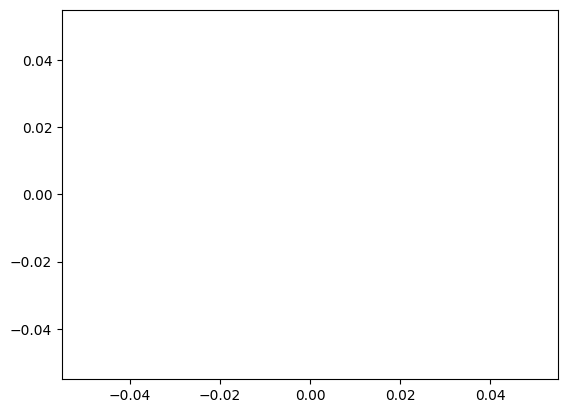

In [20]:
plt.plot(theo_deltas[26000:])

In [21]:
def fit_ar2(process):
    x2 = process.shift(2)
    x1 = process.shift(1)
    y = process
    # Linear regression to get the AR(2) coefficients
    data = pd.DataFrame({'y': y, 'x1': x1, 'x2': x2}).dropna()
    model = LinearRegression().fit(data[['x1', 'x2']], data['y'])

    y_pred = model.predict(data[['x1', 'x2']])
    residuals = data['y'] - y_pred
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.title('Residuals vs Fitted Values for AR(2) Model')
    plt.show()

    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title('QQ-Plot of Residuals for AR(2) Model')
    plt.show()
    return model.intercept_, model.coef_[0], model.coef_[1]
    

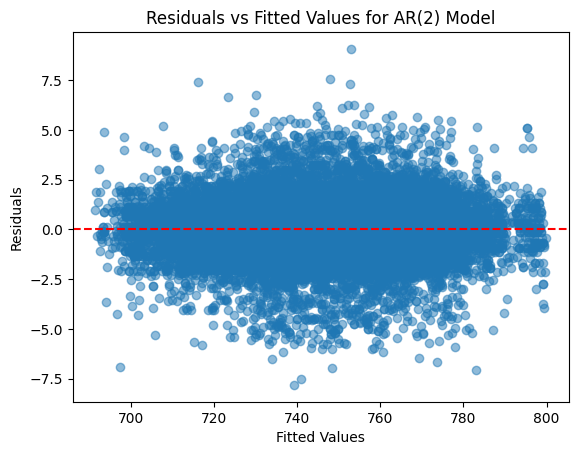

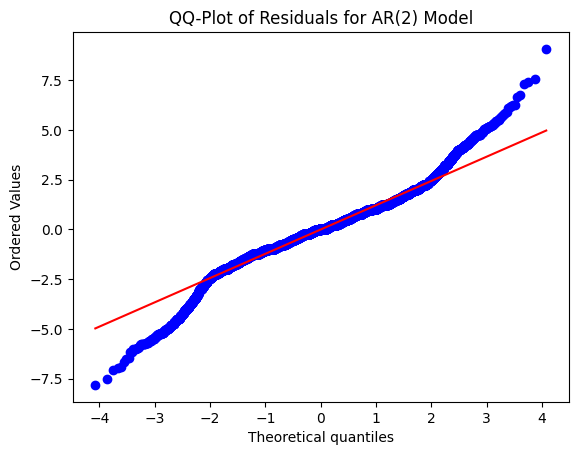

(np.float64(1.4157981163165232),
 np.float64(0.7652217580850882),
 np.float64(0.23288383705514495))

In [22]:
fit_ar2(option(4500))

In [23]:
vfe_prices = vfe_prices_r4
vfe_prices['OBI_d1'] = vfe_prices['ask_volume_1'] - vfe_prices['bid_volume_1']
tmp = vfe_prices[['ask_volume_1', 'bid_volume_1',
                  'ask_volume_2', 'bid_volume_2',
                  'ask_volume_3', 'bid_volume_3',]].replace('', '0')
tmp['total_ask_volume'] = tmp['ask_volume_1'] + tmp['ask_volume_2'].astype(int) + tmp['ask_volume_3'].astype(int)
tmp['total_bid_volume'] = tmp['bid_volume_1'] + tmp['bid_volume_2'].astype(int) + tmp['bid_volume_3'].astype(int)
vfe_prices['OBI_all'] = tmp['total_ask_volume'] - tmp['total_bid_volume']
vfe_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,OBI_d1,OBI_all
0,1,0,VELVETFRUIT_EXTRACT,5242,54,,,,,5248,54,,,,,5245.0,0.0,0,0
1,1,100,VELVETFRUIT_EXTRACT,5243,56,,,,,5248,20,5249,36,,,5245.5,0.0,-36,0
2,1,200,VELVETFRUIT_EXTRACT,5244,21,5243,36,,,5249,57,,,,,5246.5,0.0,36,0
3,1,300,VELVETFRUIT_EXTRACT,5245,18,5244,38,,,5250,56,,,,,5247.5,0.0,38,0
4,1,400,VELVETFRUIT_EXTRACT,5245,23,5244,46,,,5250,23,5251,46,,,5247.5,0.0,0,0


In [24]:
trades = trades_r4
trades['buyer'] = trades['buyer'].apply(lambda s: s.split()[1])
trades['seller'] = trades['seller'].apply(lambda s: s.split()[1])

In [25]:
trades.head()
vfe_trades = trades[trades['symbol'] == 'VELVETFRUIT_EXTRACT']

In [26]:
for i in range(len(vfe_trades)):
    ts = vfe_trades.loc[vfe_trades.index[i], 'timestamp']
    vfe_prices.loc[ts//100, 'transaction'] = vfe_trades.loc[vfe_trades.index[i], 'buyer']+';'
    vfe_prices.loc[ts//100, 'transaction'] += vfe_trades.loc[vfe_trades.index[i], 'seller']+';'
    vfe_prices.loc[ts//100, 'transaction'] += str(vfe_trades.loc[vfe_trades.index[i], 'price'])+';'
    vfe_prices.loc[ts//100, 'transaction'] += str(vfe_trades.loc[vfe_trades.index[i], 'quantity'])
    
vfe_prices.head(12)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,OBI_d1,OBI_all,transaction
0,1,0,VELVETFRUIT_EXTRACT,5242,54,,,,,5248,54,,,,,5245.0,0.0,0,0,NaN
1,1,100,VELVETFRUIT_EXTRACT,5243,56,,,,,5248,20,5249,36,,,5245.5,0.0,-36,0,NaN
2,1,200,VELVETFRUIT_EXTRACT,5244,21,5243,36,,,5249,57,,,,,5246.5,0.0,36,0,NaN
3,1,300,VELVETFRUIT_EXTRACT,5245,18,5244,38,,,5250,56,,,,,5247.5,0.0,38,0,NaN
4,1,400,VELVETFRUIT_EXTRACT,5245,23,5244,46,,,5250,23,5251,46,,,5247.5,0.0,0,0,NaN
5,1,500,VELVETFRUIT_EXTRACT,5245,17,5244,34,,,5250,51,,,,,5247.5,0.0,34,0,NaN
6,1,600,VELVETFRUIT_EXTRACT,5244,56,,,,,5246,14,5249,17,5250,39,5245.0,0.0,-42,14,NaN
7,1,700,VELVETFRUIT_EXTRACT,5243,15,5242,43,,,5248,58,,,,,5245.5,0.0,43,0,NaN
8,1,800,VELVETFRUIT_EXTRACT,5243,20,5242,45,,,5248,20,5249,45,,,5245.5,0.0,0,0,NaN
9,1,900,VELVETFRUIT_EXTRACT,5243,22,5242,30,,,5248,22,5249,30,,,5245.5,0.0,0,0,NaN


In [27]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Prepare the data
X = underlying.mid_price.values.reshape(-1, 1)
Y = np.array(option(5200)) - 0.68565758 * 100 * np.array(underlying.mid_price)

# Fit the linear regression model
model = LinearRegression().fit(X, Y)

# Print the coefficients and intercept
print("Coefficients:")
print(model.coef_)
print("Intercept:")
print(model.intercept_)

Coefficients:
[-67.88010042]
Intercept:
-3509.096657062706


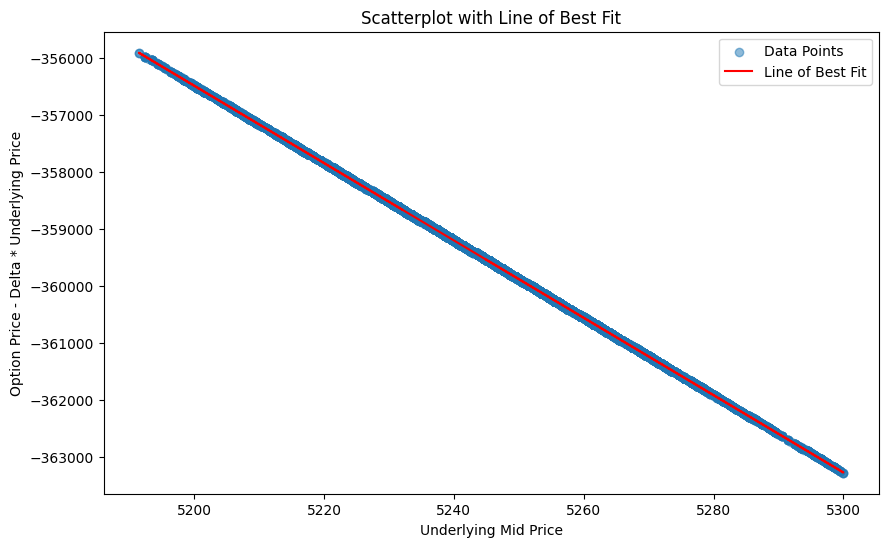

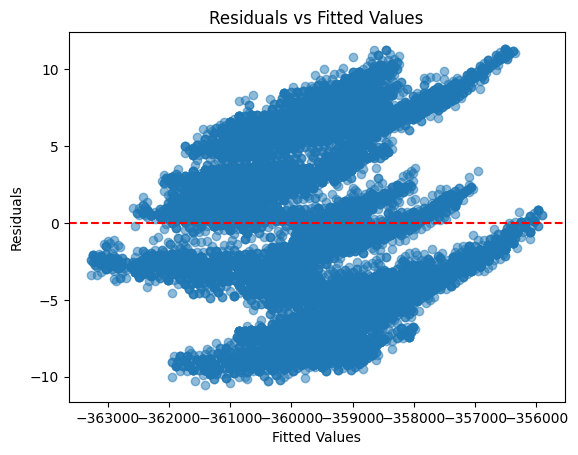

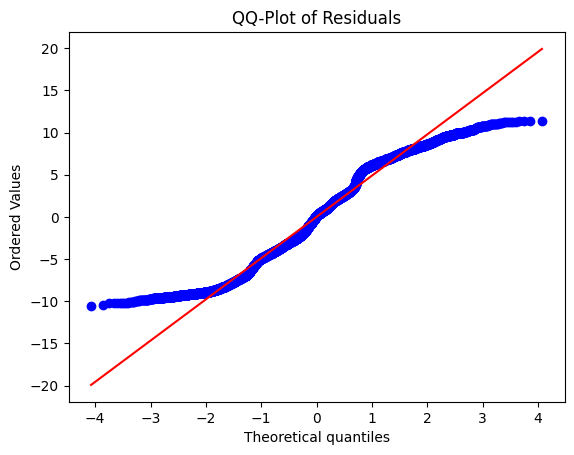

In [28]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Scatterplot with line of best fit
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.5, label='Data Points')
plt.plot(X, model.predict(X), color='red', label='Line of Best Fit')
plt.xlabel('Underlying Mid Price')
plt.ylabel('Option Price - Delta * Underlying Price')
plt.title('Scatterplot with Line of Best Fit')
plt.legend()
plt.show()

# Residuals vs fitted
y_pred = model.predict(X)
residuals = Y - y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

# QQ-plot of residuals
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ-Plot of Residuals')
plt.show()

In [29]:
def linreg_option(K):
    X = extract.values.reshape(-1, 1)
    X_quad = np.hstack([X])
    y = option(K).values
    model = LinearRegression().fit(X_quad, y)
    y_pred = model.predict(X_quad)
    plt.scatter(extract, option(K), alpha=0.5, label='Data Points')
    plt.plot(extract, y_pred, color='red', label='Linear Fit')
    plt.xlabel('Extract Mid Price')
    plt.ylabel('Option Mid Price')
    plt.title('Linear Fit of Extract Price vs Option Price')
    plt.legend()
    plt.show()

    print("Coefficients:")
    print(model.coef_)
    print("Intercept:")
    print(model.intercept_)
    residuals = y - y_pred
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.title('Residuals vs Fitted Values')
    plt.show()

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    ax.scatter(underlying.mid_price, np.array(option(K)) - model.coef_[0]*np.array(underlying.mid_price))
    ax.set_title('Option - Delta * Spot vs Spot')
    ax.set_xlabel('Spot')
    ax.set_ylabel('Option Price - Delta*100*Underlying Price')
    plt.show()

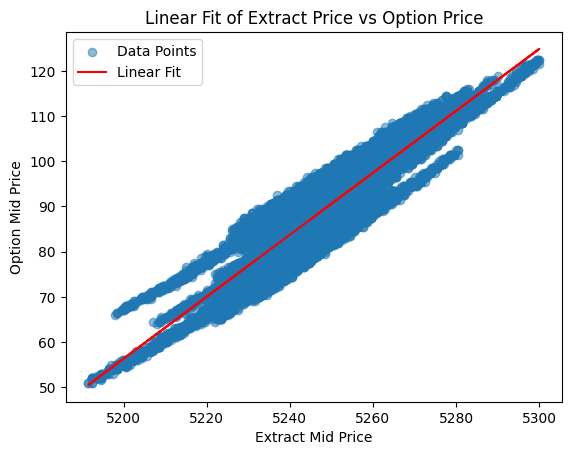

Coefficients:
[0.68565758]
Intercept:
-3509.096657061972


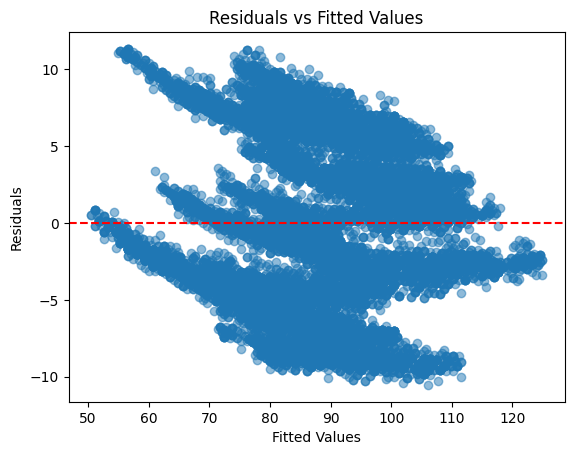

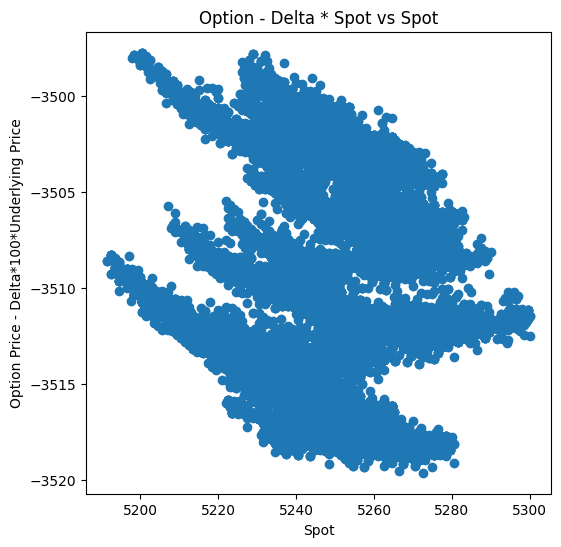

In [30]:
linreg_option(5200)

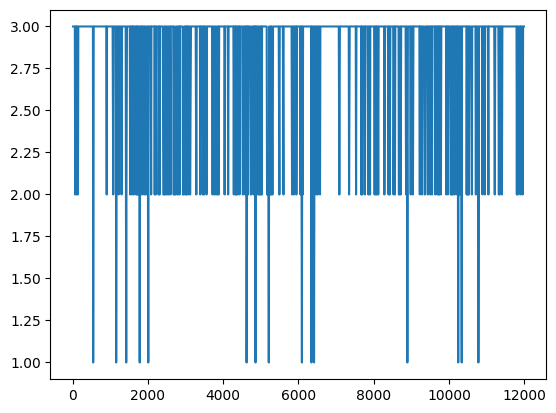

In [31]:
option_all = lambda s: prices[prices['product'] == f'VEV_{s}']
K = 5200
plt.plot((option_all(K)['ask_price_1'] - option_all(K)['bid_price_1'])[:1000])

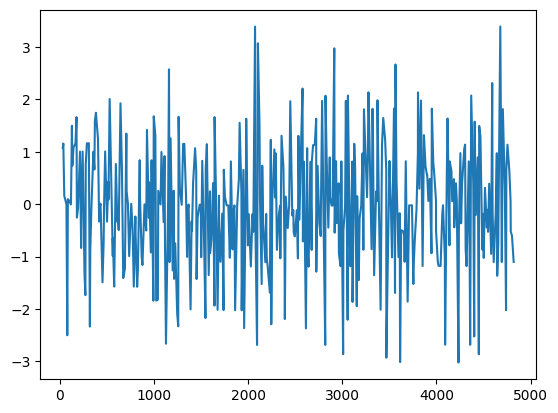

In [32]:
# Below are the spreads of the options at the given strikes
# 4k  : 21
# 4.5k: 16
# 5k  : 6
# 5.1k: 4
# 5.2k: 3
# 5.3k: 2
# 5.4k: 1/2 (1/3 vs 2/3 split)
# 5.5k: 1 (occasionally 2)
# 6k and 6.5k have spreads of 1 (nobody trades them?)
model = LinearRegression().fit(data[['x1', 'x2']], data['y'])
y_pred = model.predict(data[['x1', 'x2']])
residuals = data['y'] - y_pred
plt.plot(residuals[:400])